In [16]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

file_path = "../data/NYC.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (1458644, 11)
Sütun Adları: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


In [17]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [18]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB
Dublikat sətir: 0


In [19]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [20]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [21]:
df['trip_duration_min'] = df['trip_duration'] / 60

print("Before filtering:")
print(df['trip_duration_min'].describe())

before_n = len(df)
df_clean = df[(df['trip_duration_min'] >= 1) & (df['trip_duration_min'] <= 120)].copy()
after_n = len(df_clean)

removed = before_n - after_n
print(f"\nRows before filtering: {before_n:,}")
print(f"Rows after filtering:  {after_n:,}")
print(f"Rows removed: {removed:,} ({removed/before_n*100:.2f}%)")

print("\nAfter filtering:")
print(df_clean['trip_duration_min'].describe())

Before filtering:
count    1.458644e+06
mean     1.599154e+01
std      8.729053e+01
min      1.666667e-02
25%      6.616667e+00
50%      1.103333e+01
75%      1.791667e+01
max      5.877137e+04
Name: trip_duration_min, dtype: float64

Rows before filtering: 1,458,644
Rows after filtering:  1,447,796
Rows removed: 10,848 (0.74%)

After filtering:
count    1.447796e+06
mean     1.401459e+01
std      1.088770e+01
min      1.000000e+00
25%      6.683333e+00
50%      1.108333e+01
75%      1.793333e+01
max      1.198500e+02
Name: trip_duration_min, dtype: float64


In [22]:
for frame in (df, df_clean):
    frame['pickup_hour'] = frame['pickup_datetime'].dt.hour
    frame['pickup_weekday'] = frame['pickup_datetime'].dt.day_name()
    frame['pickup_weekday_num'] = frame['pickup_datetime'].dt.weekday  # Monday=0
    frame['pickup_month'] = frame['pickup_datetime'].dt.month
    frame['pickup_month_name'] = frame['pickup_datetime'].dt.month_name()

df[['pickup_datetime', 'pickup_hour', 'pickup_weekday', 'pickup_month_name']].head()

,pickup_datetime,pickup_hour,pickup_weekday,pickup_month_name
0,2016-03-14 17:24:55,17,Monday,March
1,2016-06-12 00:43:35,0,Sunday,June
2,2016-01-19 11:35:24,11,Tuesday,January
3,2016-04-06 19:32:31,19,Wednesday,April
4,2016-03-26 13:30:55,13,Saturday,March


In [23]:
hourly_counts = df.groupby('pickup_hour').size()
peak_hour = hourly_counts.idxmax()
offpeak_hour = hourly_counts.idxmin()
print(f"Peak hour: {peak_hour}:00 - {peak_hour+1}:00 -> {hourly_counts[peak_hour]:,} trips")
print(f"Off-peak hour: {offpeak_hour}:00 - {offpeak_hour+1}:00 -> {hourly_counts[offpeak_hour]:,} trips")
hourly_counts.sort_values(ascending=False).head(5).to_frame('trip_count')

Peak hour: 18:00 - 19:00 -> 90,600 trips
Off-peak hour: 5:00 - 6:00 -> 15,002 trips


,trip_count
pickup_hour,
18,90600
19,90308
21,84185
20,84072
22,80492


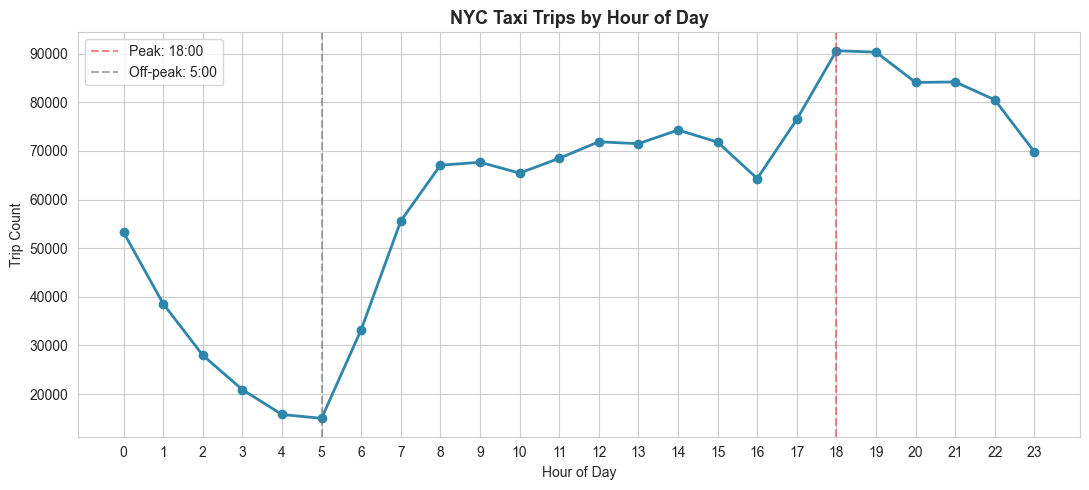

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hourly_counts.index, hourly_counts.values, marker='o', color='#2E86AB', linewidth=2)
ax.axvline(peak_hour, color='#E63946', linestyle='--', alpha=0.6, label=f'Peak: {peak_hour}:00')
ax.axvline(offpeak_hour, color='#6C757D', linestyle='--', alpha=0.6, label=f'Off-peak: {offpeak_hour}:00')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trip Count')
ax.set_title('NYC Taxi Trips by Hour of Day')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('trips_by_hour.png', dpi=120)
plt.show()

In [25]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df.groupby('pickup_weekday').size().reindex(weekday_order)
is_weekend = df['pickup_weekday_num'].isin([5, 6])
weekend_avg = df[is_weekend].groupby('pickup_weekday_num').size().mean()
weekday_avg = df[~is_weekend].groupby('pickup_weekday_num').size().mean()
print(f"Average trips per weekday (Mon-Fri): {weekday_avg:,.0f}")
print(f"Average trips per weekend day (Sat-Sun): {weekend_avg:,.0f}")
print(f"Busiest day: {weekday_counts.idxmax()} ({weekday_counts.max():,} trips)")
print(f"Quietest day: {weekday_counts.idxmin()} ({weekday_counts.min():,} trips)")

weekday_counts.to_frame('trip_count')

Average trips per weekday (Mon-Fri): 208,482
Average trips per weekend day (Sat-Sun): 208,117
Busiest day: Friday (223,533 trips)
Quietest day: Monday (187,418 trips)


,trip_count
pickup_weekday,
Monday,187418
Tuesday,202749
Wednesday,210136
Thursday,218574
Friday,223533
Saturday,220868
Sunday,195366


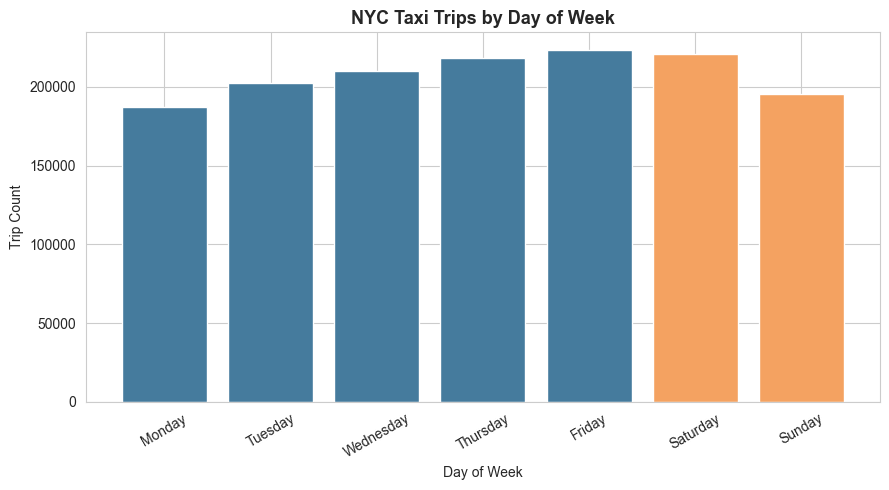

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#457B9D' if d not in ('Saturday', 'Sunday') else '#F4A261' for d in weekday_order]
ax.bar(weekday_order, weekday_counts.values, color=colors)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Trip Count')
ax.set_title('NYC Taxi Trips by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('trips_by_weekday.png', dpi=120)
plt.show()

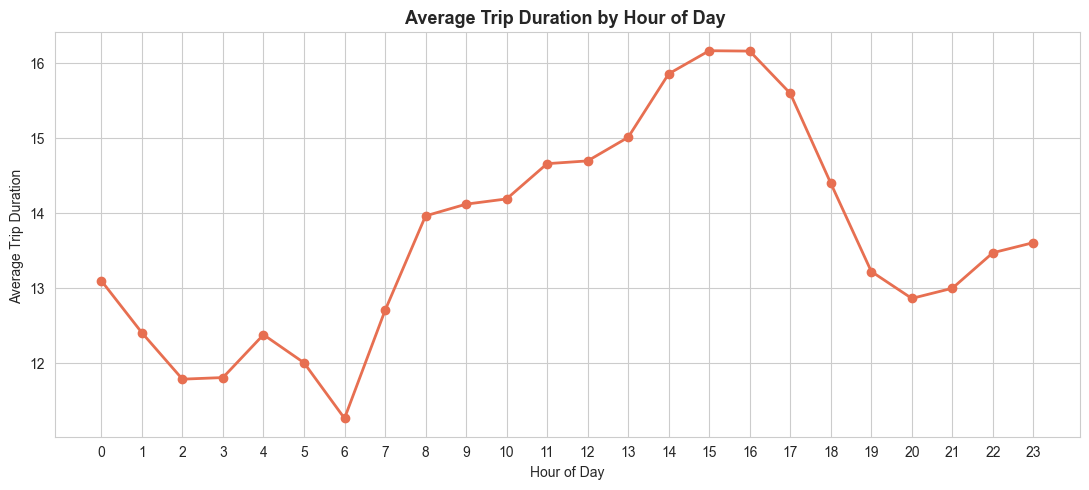

Longest average duration hour: 15:00 (16.2 min)
Shortest average duration hour: 6:00 (11.3 min)


In [28]:
duration_by_hour = df_clean.groupby('pickup_hour')['trip_duration_min'].mean()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(duration_by_hour.index, duration_by_hour.values, marker='o', color='#E76F51', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Trip Duration ')
ax.set_title('Average Trip Duration by Hour of Day ')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('avg_duration_by_hour.png', dpi=120)
plt.show()
print(f"Longest average duration hour: {duration_by_hour.idxmax()}:00 ({duration_by_hour.max():.1f} min)")
print(f"Shortest average duration hour: {duration_by_hour.idxmin()}:00 ({duration_by_hour.min():.1f} min)")

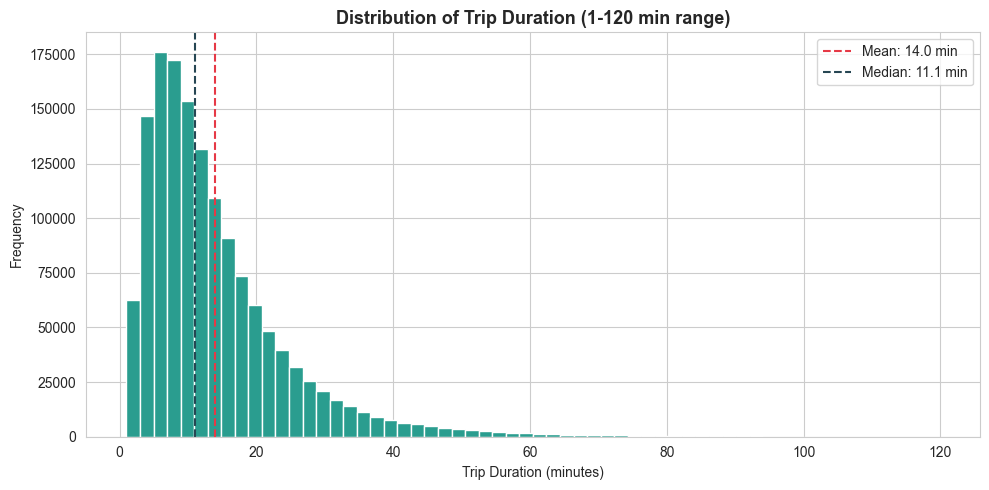

count    1.447796e+06
mean     1.401459e+01
std      1.088770e+01
min      1.000000e+00
25%      6.683333e+00
50%      1.108333e+01
75%      1.793333e+01
max      1.198500e+02
Name: trip_duration_min, dtype: float64


In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['trip_duration_min'], bins=60, color='#2A9D8F', edgecolor='white')
ax.axvline(df_clean['trip_duration_min'].mean(), color='#E63946', linestyle='--', label=f"Mean: {df_clean['trip_duration_min'].mean():.1f} min")
ax.axvline(df_clean['trip_duration_min'].median(), color='#264653', linestyle='--', label=f"Median: {df_clean['trip_duration_min'].median():.1f} min")
ax.set_xlabel('Trip Duration (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Trip Duration (1-120 min range)')
ax.legend()
plt.tight_layout()
plt.savefig('duration_histogram.png', dpi=120)
plt.show()
print(df_clean['trip_duration_min'].describe())

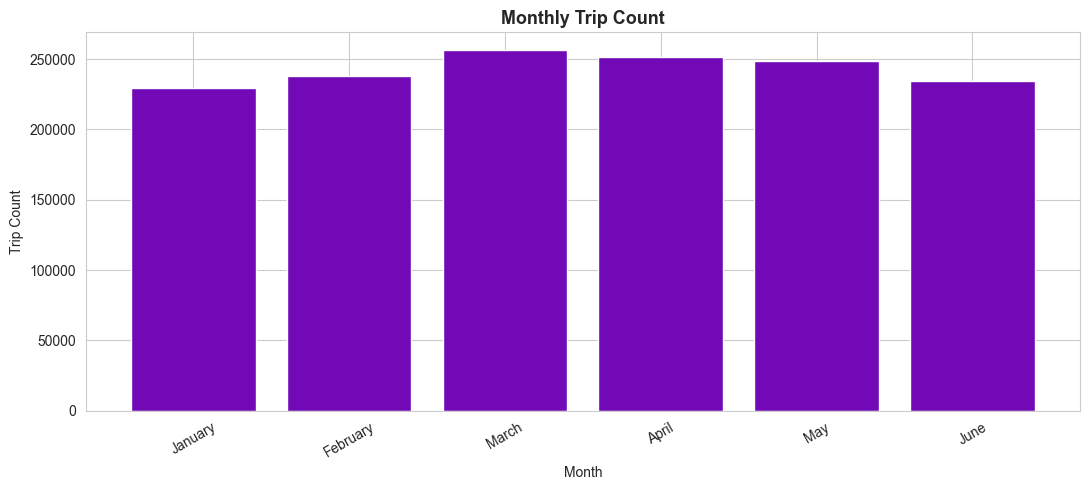

,trip_count
pickup_month_name,
January,229707.0
February,238300.0
March,256189.0
April,251645.0
May,248487.0
June,234316.0


In [30]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_counts = df.groupby('pickup_month_name').size().reindex(month_order).dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(monthly_counts.index, monthly_counts.values, color='#7209B7')
ax.set_xlabel('Month')
ax.set_ylabel('Trip Count')
ax.set_title('Monthly Trip Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=120)
plt.show()
monthly_counts.to_frame('trip_count')

In [31]:
monthly_duration = df_clean.groupby('pickup_month_name')['trip_duration_min'].mean().reindex(month_order).dropna()
print("Average trip duration by month:")
print(monthly_duration.round(2))
print(f"\nHighest average duration month: {monthly_duration.idxmax()} ({monthly_duration.max():.2f} min)")

Average trip duration by month:
pickup_month_name
January     13.24
February    13.23
March       13.69
April       14.20
May         14.79
June        14.91
Name: trip_duration_min, dtype: float64

Highest average duration month: June (14.91 min)


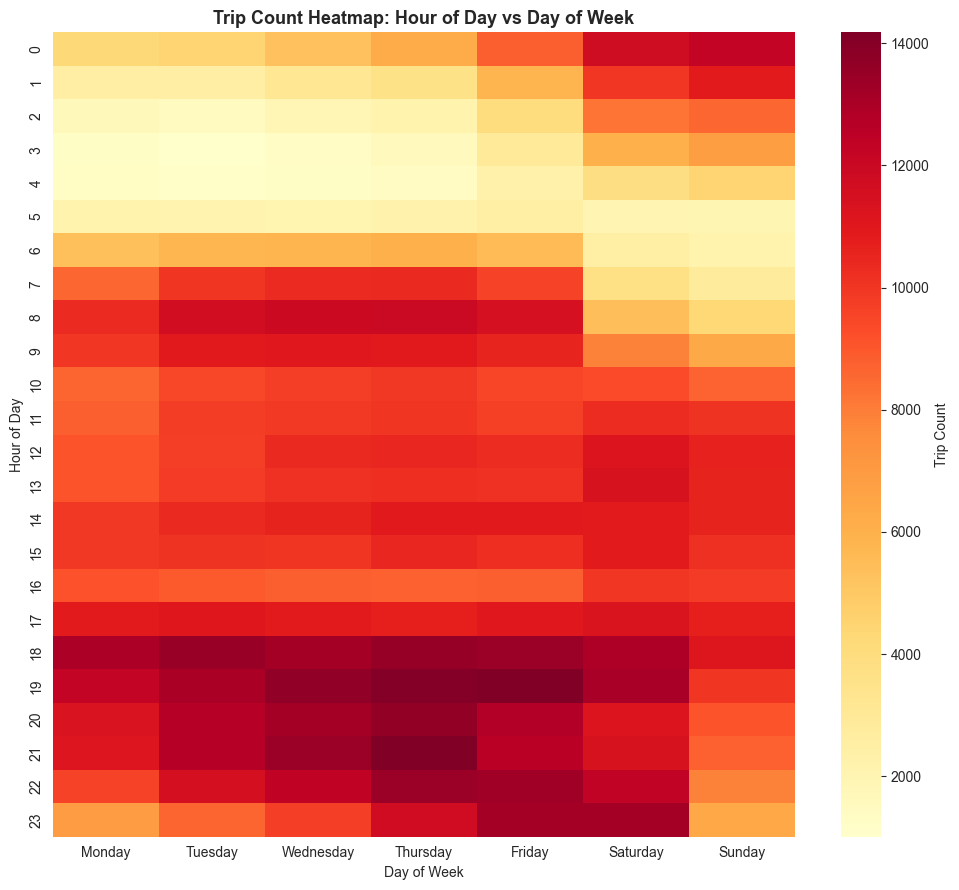

In [32]:
heatmap_data = df.pivot_table(index='pickup_hour', columns='pickup_weekday',
                               values='id', aggfunc='count').reindex(columns=weekday_order)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Trip Count'})
ax.set_title('Trip Count Heatmap: Hour of Day vs Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('hour_weekday_heatmap.png', dpi=120)
plt.show()

           avg_duration_min  median_duration_min  trip_count  share_pct
vendor_id                                                              
1                     13.93                11.05      673164       46.5
2                     14.08                11.12      774632       53.5


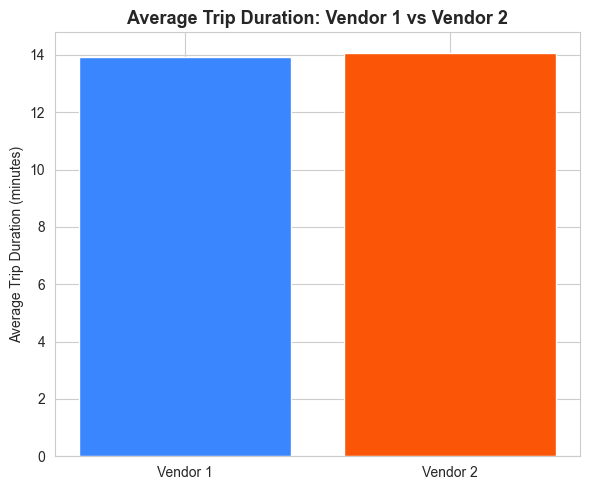

In [33]:
vendor_duration = df_clean.groupby('vendor_id')['trip_duration_min'].agg(['mean', 'median', 'count'])
vendor_duration.columns = ['avg_duration_min', 'median_duration_min', 'trip_count']
vendor_duration['share_pct'] = (vendor_duration['trip_count'] / vendor_duration['trip_count'].sum() * 100).round(1)
print(vendor_duration.round(2))
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Vendor 1', 'Vendor 2'], vendor_duration['avg_duration_min'], color=['#3A86FF', '#FB5607'])
ax.set_ylabel('Average Trip Duration (minutes)')
ax.set_title('Average Trip Duration: Vendor 1 vs Vendor 2')
plt.tight_layout()
plt.savefig('vendor_comparison.png', dpi=120)
plt.show()